<a href="https://colab.research.google.com/github/anur8591/Netflix-Movie-Recommendation-Engine/blob/main/Copy_of_Netflix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Data1:https://drive.google.com/file/d/19mXC1IMIm09ytUadfo1OK17L0uBoX_qQ/view?usp=drive_link
# Data2:https://drive.google.com/file/d/1airOXLzNtclGb3VXDMJMia1EUkzrx7i_/view?usp=drive_link

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:
netflix_dataset=pd.read_csv('/content/drive/MyDrive/Netflix/Copy of combined_data_1.txt.zip',header=None,names=['Cust_Id','Ratings'],usecols=[0,1])

In [5]:
netflix_dataset

# 1: is the movie iD
# 1488844 its a customer id like for move 1: this customer has rated this much and all ....
# nearly 5K movies there in this dataset
# this data is messed up in the customer column movie id is also there and customer id is also there


,Cust_Id,Ratings
0,1:,NaN
1,1488844,3.0
2,822109,5.0
3,885013,4.0
4,30878,4.0
...,...,...
24058258,2591364,2.0
24058259,1791000,2.0
24058260,512536,5.0
24058261,988963,3.0


In [6]:
#moviecount
#customer count
#ratings count
#stars count

In [7]:
netflix_dataset.isnull().sum()

,0
Cust_Id,0
Ratings,4499


In [8]:
movie_count=netflix_dataset.isnull().sum()
movie_count=movie_count['Ratings']
movie_count

# from this value 4499 we come to know this many movies are present in this dataset


4499

In [9]:
total_count=netflix_dataset['Cust_Id'].nunique()
total_count
# here we removed the unique id from data set and we got this value 475257
# but this inclue movie id too, so we have to eleminate the movie id from this value 475257

475257

In [10]:
customer_count=total_count-movie_count
# here we removed the movie id from the total number of unique value i.e 475257

In [11]:
customer_count
# here we removed all the movie id and we got this value 470758
# this is the unique customer value it meant this many unique costumer id we have in the data set
# conclusion total we have = 475257 unique id including movie and customer id
# and we 470758 unique customer id from all unique id

470758

In [12]:
rating_count=netflix_dataset['Cust_Id'].count()-movie_count
# here we removing null value from the rating column to get the customer rating

In [13]:
rating_count

24053764

In [71]:
stars=netflix_dataset['Ratings'].value_counts()
stars

,count
Ratings,
4.0,6695722
3.0,5808712
5.0,4364792
2.0,1987927
1.0,838683


In [16]:
movie_id=None
movie_np=[]

for customer in netflix_dataset['Cust_Id']:
  if ":" in customer:
    movie_id=int(customer.replace(":",""))   #1: --> 1 we converted that colen(:) into 1

  movie_np.append(movie_id)

In [17]:
movie_np

[1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,
 1,


In [18]:
netflix_dataset['Movie_Id']=movie_np

In [19]:
netflix_dataset

,Cust_Id,Ratings,Movie_Id
0,1:,NaN,1
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [20]:
netflix_dataset.dropna(inplace=True)

In [21]:
netflix_dataset

,Cust_Id,Ratings,Movie_Id
1,1488844,3.0,1
2,822109,5.0,1
3,885013,4.0,1
4,30878,4.0,1
5,823519,3.0,1
...,...,...,...
24058258,2591364,2.0,4499
24058259,1791000,2.0,4499
24058260,512536,5.0,4499
24058261,988963,3.0,4499


In [22]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   object 
 1   Ratings   float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(1), object(1)
memory usage: 734.1+ MB


In [23]:
netflix_dataset['Cust_Id']=netflix_dataset['Cust_Id'].astype(int)

In [24]:
netflix_dataset.info()

<class 'pandas.core.frame.DataFrame'>
Index: 24053764 entries, 1 to 24058262
Data columns (total 3 columns):
 #   Column    Dtype  
---  ------    -----  
 0   Cust_Id   int64  
 1   Ratings   float64
 2   Movie_Id  int64  
dtypes: float64(1), int64(2)
memory usage: 734.1 MB


In [25]:
# be back by 9:45

In [26]:
# user = 0
# movies = 2

In [27]:
# no.of rewie count for movie
# no 0f rewie by cust

In [72]:
movie_re_count=netflix_dataset['Movie_Id'].value_counts()
movie_re_count

,count
Movie_Id,
1905,142993
2452,121278
571,120186
4306,119073
3860,118609
...,...
106,717
2324,712
1817,711


In [73]:
bench_mark=round(movie_re_count.quantile(0.6),0)  #48.0 --> 48
bench_mark

5035.0

In [32]:
drop_movie_index=movie_re_count[movie_re_count<bench_mark].index

In [33]:
drop_movie_index

Index([1598, 1733, 1647, 4099, 1616, 1446,  263, 4259,  160, 1988,
       ...
       1858, 4035, 3693, 2805,  820, 4294,  915, 3656, 4338, 4362],
      dtype='int64', name='Movie_Id', length=2699)

In [34]:
len(drop_movie_index)

2699

In [35]:
cust_rew_count=netflix_dataset['Cust_Id'].value_counts()

In [36]:
cust_rew_count

,count
Cust_Id,
305344,4467
387418,4422
2439493,4195
1664010,4019
2118461,3769
...,...
1300341,1
2550360,1
11848,1


In [37]:
bench_mark_cus=round(cust_rew_count.quantile(0.6),0)  #48.0 --> 48

In [38]:
bench_mark_cus

36.0

In [39]:
drop_cust_index=cust_rew_count[cust_rew_count<bench_mark_cus].index

In [40]:
drop_cust_index

Index([2194851,  600295, 1739398, 1157368,  532108, 2157249,  256134,  640441,
       1272324, 1346990,
       ...
       1969065,  899932,  611596, 2147176,  811650, 1300341, 2550360,   11848,
        930788,  594210],
      dtype='int64', name='Cust_Id', length=282042)

In [41]:
drop_movie_index,drop_cust_index

(Index([1598, 1733, 1647, 4099, 1616, 1446,  263, 4259,  160, 1988,
        ...
        1858, 4035, 3693, 2805,  820, 4294,  915, 3656, 4338, 4362],
       dtype='int64', name='Movie_Id', length=2699),
 Index([2194851,  600295, 1739398, 1157368,  532108, 2157249,  256134,  640441,
        1272324, 1346990,
        ...
        1969065,  899932,  611596, 2147176,  811650, 1300341, 2550360,   11848,
         930788,  594210],
       dtype='int64', name='Cust_Id', length=282042))

In [42]:
netflix_dataset=netflix_dataset[~netflix_dataset['Movie_Id'].isin(drop_movie_index)]  #1598
netflix_dataset=netflix_dataset[~netflix_dataset['Cust_Id'].isin(drop_cust_index)]

In [43]:
# df[(df[col]>=LB) &(df[col]<=Ub)]
# .drop()  = > columns

In [44]:
netflix_dataset

,Cust_Id,Ratings,Movie_Id
696,712664,5.0,3
697,1331154,4.0,3
698,2632461,3.0,3
699,44937,5.0,3
700,656399,4.0,3
...,...,...,...
24056842,1055714,5.0,4496
24056843,2643029,4.0,4496
24056844,267802,4.0,4496
24056845,1559566,3.0,4496


In [45]:
# Till here we done EDA part for one data set now second dataset
# we don't need EDA for second data set it's already clear
# now mearge that table and create one dataset which is containing both data from 1 & 2

In [46]:
movie_title=pd.read_csv('/content/drive/MyDrive/Netflix/Copy of movie_titles.csv',encoding='ISO-8859-1',header=None,names=['Movie_Id','Year','Name'],usecols=[0,1,2])

In [47]:
movie_title

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [48]:
# now we done with EDA and all, Now Model building

# Notes:
# SVD break the complex problem into the small one like i have 27 i can alos se its as [3*3*3]
# see 27 is break into 3 it is use in matrices

# ************ watch Netflix class again for good understanding a lot of imp was covered in the 3rd class ***************

Text(0.5, 1.0, 'Distribution of Ratings')

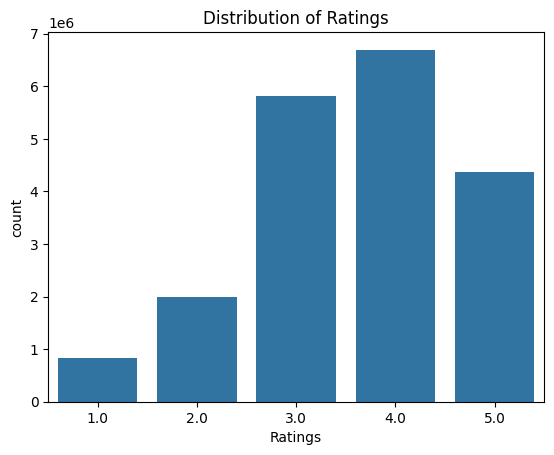

In [76]:
sns.countplot(x="Ratings", data=netflix_dataset)
plt.title("Distribution of Ratings")

In [78]:
top_movies = netflix_dataset.groupby('Movie_Id')['Ratings'].mean().sort_values(ascending=False).head(10)
top_movies

,Ratings
Movie_Id,
3456,4.667269
2102,4.588016
3444,4.520370
4238,4.495253
1476,4.466834
2568,4.463280
4427,4.456323
1947,4.438146
1256,4.436311


In [49]:
!pip install numpy==1.26.4

# some time this numpy is not integrated with some libraries
# that why we have to install this version

In [50]:
!pip install scikit-surprise
# in this lib we have SVD

  Using cached scikit_surprise-1.1.4.tar.gz (154 kB)
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for scikit-surprise: filename=scikit_surprise-1.1.4-cp312-cp312-linux_x86_64.whl size=2554983 sha256=aba4ec15e365e839f0f2f2740ec0ef40e2a85bb11c460f60db4c71451a37f389
  Stored in directory: /root/.cache/pip/wheels/75/fa/bc/739bc2cb1fbaab6061854e6cfbb81a0ae52c92a502a7fa454b
Successfully built scikit-surprise


| Component        | Purpose                                                                                   |
| ---------------- | ----------------------------------------------------------------------------------------- |
| `SVD`            | Matrix Factorization algorithm — one of the most popular collaborative filtering models.  |
| `Reader`         | Defines the format of your rating data (e.g., rating scale 1–5, file type, column order). |
| `Dataset`        | Loads your data into a Surprise-compatible structure.                                     |
| `cross_validate` | Performs model evaluation using k-fold cross-validation (like in scikit-learn).           |


-fold cross-validation as an example (used in cross_validate()):

Split dataset into k equal parts (called folds).
Example: For 5-fold CV → data is split into 5 subsets.

Perform k iterations of training/testing:

In each iteration:

Use k-1 folds for training.

Use 1 fold for testing.

Rotate the test fold each time.

Compute your evaluation metric (e.g., RMSE, MAE, Accuracy) for each fold.

Average all the metric values — that’s your final performance score.

| Fold | Training Data | Testing Data | RMSE (Example) |
| ---- | ------------- | ------------ | -------------- |
| 1    | Folds 2–5     | Fold 1       | 0.88           |
| 2    | Folds 1,3–5   | Fold 2       | 0.84           |
| 3    | Folds 1–2,4–5 | Fold 3       | 0.86           |
| 4    | Folds 1–3,5   | Fold 4       | 0.85           |
| 5    | Folds 1–4     | Fold 5       | 0.87           |


In [51]:
from surprise import SVD,Reader,Dataset
from surprise.model_selection import cross_validate

In [52]:
reader=Reader()

In [53]:
# usual models - > csv - training
# SVD - CSVx , suprice server

In [54]:
# object -> name, class, age , : obj.name

In [55]:
data=Dataset.load_from_df(netflix_dataset[['Movie_Id','Cust_Id','Ratings']][:100000],reader)

# we have crores of data so it will take time
# first we are testing on small dataset i.e == 10K dataset for fast processing


In [56]:
data

In [57]:
model=SVD()

In [75]:
cross_validate(model,data,measures=['RMSE'],cv=3)

# we are using cross validation it will divide the dataset like
# i given the cv=3 it means my 10K data set will divide into 3 part

{'test_rmse': array([1.0168447 , 1.02199169, 1.02151607]),
 'fit_time': (3.1477952003479004, 1.5135445594787598, 1.5539584159851074),
 'test_time': (0.8203225135803223, 0.1561579704284668, 0.1581096649169922)}

In [59]:
user_rating=netflix_dataset[netflix_dataset['Cust_Id']==1331154]

In [60]:
user_rating

,Cust_Id,Ratings,Movie_Id
697,1331154,4.0,3
5178,1331154,4.0,8
31460,1331154,3.0,18
92840,1331154,4.0,30
224761,1331154,3.0,44
...,...,...,...
23439584,1331154,4.0,4389
23546489,1331154,2.0,4402
23649431,1331154,4.0,4432
23844441,1331154,3.0,4472


In [61]:
user_1331154=movie_title.copy()  #45678
user_1331154

,Movie_Id,Year,Name
0,1,2003.0,Dinosaur Planet
1,2,2004.0,Isle of Man TT 2004 Review
2,3,1997.0,Character
3,4,1994.0,Paula Abdul's Get Up & Dance
4,5,2004.0,The Rise and Fall of ECW
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [62]:
user_1331154=user_1331154[~user_1331154['Movie_Id'].isin(drop_movie_index)]

In [63]:
user_1331154

,Movie_Id,Year,Name
2,3,1997.0,Character
4,5,2004.0,The Rise and Fall of ECW
5,6,1997.0,Sick
7,8,2004.0,What the #$*! Do We Know!?
15,16,1996.0,Screamers
...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...
17766,17767,2004.0,Fidel Castro: American Experience
17767,17768,2000.0,Epoch
17768,17769,2003.0,The Company


In [64]:
user_1331154['Estimated']=user_1331154['Movie_Id'].apply(lambda x:model.predict(1331154,x).est)

/tmp/ipykernel_989/374072800.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154['Estimated']=user_1331154['Movie_Id'].apply(lambda x:model.predict(1331154,x).est)


In [65]:
est=[]
for x in user_1331154['Movie_Id']:
  temp=model.predict(1331154,x).est
  est.append(temp)

user_1331154['Estimated']=est

# without lambda function


/tmp/ipykernel_989/1592205209.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  user_1331154['Estimated']=est


In [66]:
user_1331154

,Movie_Id,Year,Name,Estimated
2,3,1997.0,Character,3.577527
4,5,2004.0,The Rise and Fall of ECW,3.577527
5,6,1997.0,Sick,3.577527
7,8,2004.0,What the #$*! Do We Know!?,3.577527
15,16,1996.0,Screamers,3.577527
...,...,...,...,...
17765,17766,2002.0,Where the Wild Things Are and Other Maurice Se...,3.577527
17766,17767,2004.0,Fidel Castro: American Experience,3.577527
17767,17768,2000.0,Epoch,3.577527
17768,17769,2003.0,The Company,3.577527


In [67]:
user_1331154=user_1331154.sort_values('Estimated',ascending=False)

In [68]:
user_1331154.head()

,Movie_Id,Year,Name,Estimated
13874,13875,1982.0,Gilbert and Sullivan: The Mikado,3.889290
17450,17451,2000.0,Along for the Ride,3.828427
10373,10374,1997.0,Goosebumps: Scary House,3.815704
14034,14035,1993.0,Italian Movie,3.791254
11042,11043,1970.0,Mary Tyler Moore: Season 1,3.789206


In [69]:
#how we can increase the accuracy of the recomendation  -> add more factors  - genere , actors , lamgauge , year, directors,
#Embedding